# 520600 首轮研究复核

## tl;dr
HHI＋HTI 在本轮 30 分钟外测中将残差波动降至约 19.43bp；结果为价格风险研究，不含费用。

## Context & Methods
97 个可用日、滚动 60 日训练、37 日外测。

### Key Assumptions
一分钟 LAST、强制现金替代、日终结算率仅用于人民币事后核算；只研究同日下午，不跨日或合约。

In [1]:
from pathlib import Path
import json, pandas as pd, numpy as np
root=Path.cwd()
if not (root/'reports').exists(): root=root.parent
m=pd.read_csv(root/'reports/model_comparison.csv')
folds=pd.read_csv(root/'reports/folds.csv')
res=pd.read_parquet(root/'reports/oos_residuals.parquet')
print('Folds:',len(folds),'OOS days:',res.date.nunique())

Folds: 148 OOS days: 37


## Data
切分与样本一致性检查。

In [2]:
assert (folds.train_end<folds.test_date).all()
for h,part in res.groupby('horizon'):
    counts=part.groupby('model').size()
    assert counts.nunique()==1
    print(h,'min:',counts.iloc[0],'labels per method')

5 min: 4255 labels per method
15 min: 3885 labels per method
30 min: 3330 labels per method
60 min: 2220 labels per method


## Results
从保存的逐样本残差独立重算关键指标。

In [3]:
p=res[(res.horizon==30)&(res.model=='HHI_HTI_fixed_pair')]
value=1-p.residual.var()/p.y.var()
expected=m[(m.horizon==30)&(m.model=='HHI_HTI_fixed_pair')].iloc[0]
assert abs(value-expected.variance_reduction)<1e-12
print('30m residual std bp:',p.residual.std()*10000)
print('30m variance reduction:',value)
m[m.horizon==30][['model','residual_std_bps','variance_reduction']].sort_values('residual_std_bps')

30m residual std bp: 19.430026244677897
30m variance reduction: 0.7228432891900547


,model,residual_std_bps,variance_reduction
28,HHI_HTI_fixed_pair,19.430026,0.722843
25,03032,19.781131,0.712736
32,selected,19.843393,0.710925
30,HTI_FUT,20.029737,0.705470
26,03033,20.096703,0.703498
27,HHI_FUT,21.360272,0.665041
29,HSI_FUT,21.722577,0.653581
23,02828,22.256687,0.636337
22,02800,24.746434,0.550423
24,02845,34.598036,0.121217


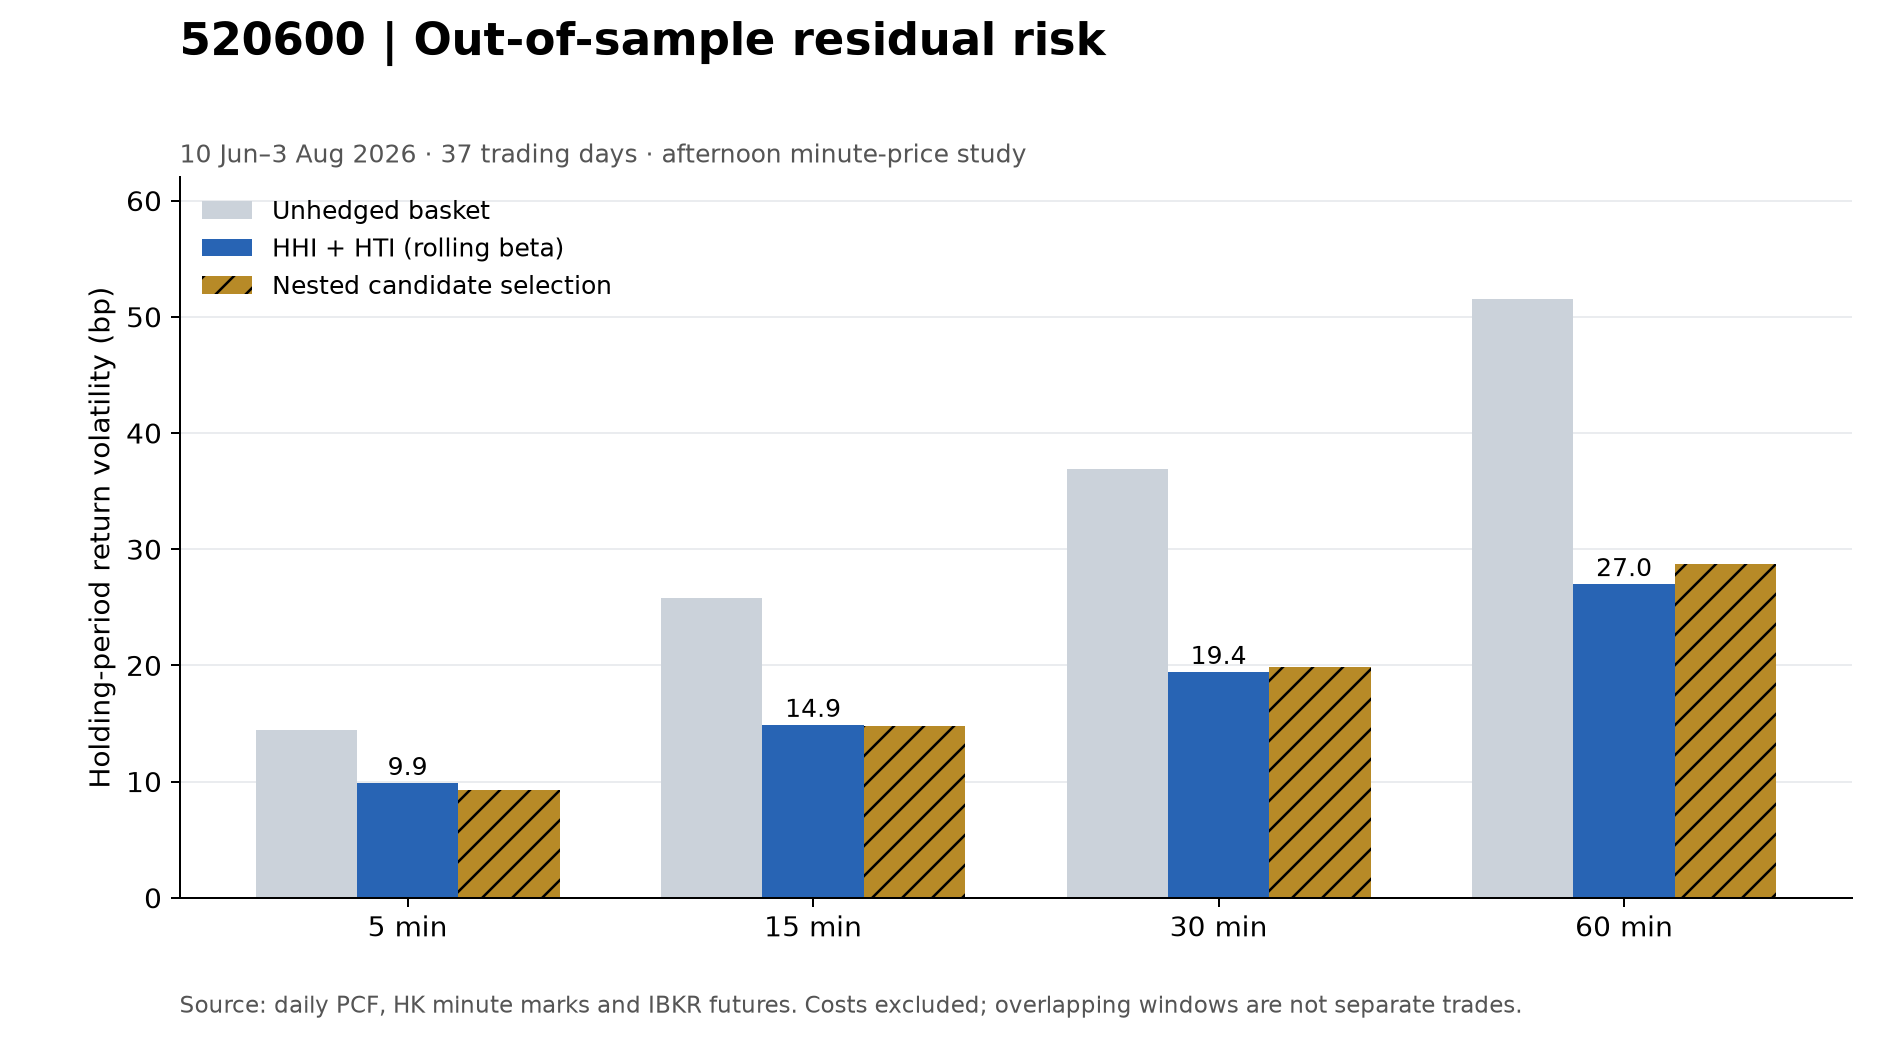

In [4]:
from IPython.display import Image,display
display(Image(filename=str(root/'reports/residual_risk.png')))

In [5]:
s=pd.read_csv(root/'reports/sensitivity.csv')
s[(s.horizon==30)&(s.model=='HHI_HTI_fixed_pair')][['scenario','days','samples','variance_reduction']]

,scenario,days,samples,variance_reduction
33,fresh_endpoint_2%_evaluation_subset,36,830,0.660010
36,fresh_endpoint_5%_evaluation_subset,37,1568,0.702998
39,hedge_timestamp_shift_-1m_frozen_weights,37,3293,0.676736
41,hedge_timestamp_shift_+1m_frozen_weights,37,3293,0.737272
43,fresh_2pct_refit,36,830,0.653446
46,exclude_suspended_days_refit,18,1620,0.744163


## Takeaways
先保留简单 HHI＋HTI 与 HTI 单腿对照；复杂选择未稳定胜出。正式结果、冻结停牌权重、三天复杂权益剔除和事件源缺口详见 reports/520600_首轮结果.md。